<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Обучение</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Выводы</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

# Проект для «Викишоп» с BERT

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию.

Обучите модель классифицировать комментарии на позитивные и негативные. В вашем распоряжении набор данных с разметкой о токсичности правок.

Постройте модель со значением метрики качества *F1* не меньше 0.75.

**Инструкция по выполнению проекта**

1. Загрузите и подготовьте данные.
2. Обучите разные модели.
3. Сделайте выводы.

Для выполнения проекта применять *BERT* необязательно, но вы можете попробовать.

**Описание данных**

Данные находятся в файле `toxic_comments.csv`. Столбец *text* в нём содержит текст комментария, а *toxic* — целевой признак.

## Подготовка

In [ ]:
!pip install transformers -q
!pip install torch -q

In [ ]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split, GridSearchCV, \
    RandomizedSearchCV, StratifiedKFold

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer

import numpy as np
import pandas as pd
from tqdm import notebook

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

from imblearn.under_sampling import RandomUnderSampler

import math

In [ ]:
import transformers
from transformers import AutoTokenizer, AutoModel

In [ ]:
import torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 36.6 MB/s eta 0:00:00


In [ ]:
RANDOM_STATE = 42

In [ ]:
def correct_path (csv_name):
    if not os.path.exists(csv_name):
        return '/datasets/' + csv_name
    return csv_name

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("unitary/toxic-bert")
model = AutoModel.from_pretrained("unitary/toxic-bert")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/811 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [ ]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/toxic_comments.csv')

In [ ]:
df.shape

(159292, 3)

In [ ]:
df['toxic'].value_counts(normalize=True)

,proportion
toxic,
0,0.898388
1,0.101612


In [ ]:
df['toxic'].value_counts()

,count
toxic,
0,143106
1,16186


In [ ]:
X = df['text'] #.sample(100)
y = df['toxic'] #.sample(100)

## Обучение

In [ ]:
def build_embeddings (texts, tokenizer, model):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model.to(device)  # Переносим модель на GPU


    # Токенизация с padding и truncation
    encoded_inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )

    # Переносим тензоры на GPU
    input_ids = encoded_inputs["input_ids"].to(device)
    attention_mask = encoded_inputs["attention_mask"].to(device)

    embeddings = []

    # Прогон по батчам
    batch_size = 128
    n_samples = input_ids.size(0)
    for i in notebook.tqdm(range(0, n_samples, batch_size), desc="Computing embeddings"):
        input_ids_batch = input_ids[i:i+batch_size].to(device)
        attention_mask_batch = attention_mask[i:i+batch_size].to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids_batch, attention_mask=attention_mask_batch)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]  # (batch_size, hidden_size)
            embeddings.append(cls_embeddings.cpu())

    # Объединяем
    final_embeddings = torch.cat(embeddings, dim=0)  # (n_samples, hidden_size)

    return final_embeddings.numpy()

In [ ]:
%%time
X = build_embeddings(X.tolist(), tokenizer, model)
X = pd.DataFrame(X)
X

Computing embeddings:   0%|          | 0/1245 [00:00<?, ?it/s]

CPU times: user 40min 12s, sys: 9.59 s, total: 40min 22s
Wall time: 40min 35s


,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,-0.558511,-1.047665,0.719949,-0.483062,1.028294,0.293321,-0.035680,-0.038888,-0.472506,-0.520920,...,-0.638225,-1.209703,0.317886,-0.647595,0.119994,0.626522,-0.517144,-0.711591,0.524906,0.112770
1,-0.593371,-0.998131,0.623939,-0.454594,0.911482,0.284729,-0.078003,0.016091,-0.399519,-0.664109,...,-0.606167,-1.212724,0.202401,-0.658875,0.257863,0.913928,-0.441598,-0.692219,0.463358,0.108212
2,-0.612209,-0.865758,0.748589,-0.565627,0.853180,0.364377,-0.035331,-0.004912,-0.409727,-0.703042,...,-0.605378,-1.240449,0.336927,-0.647340,0.287236,0.766124,-0.270079,-0.612619,0.509027,0.137326
3,-0.569208,-0.929469,0.589398,-0.342743,0.978539,0.195408,-0.203038,0.088817,-0.417226,-0.665862,...,-0.464487,-1.251387,0.195846,-0.691162,0.105117,0.881208,-0.636687,-0.704349,0.381343,0.105702
4,-0.794516,-0.845893,0.889402,-0.558252,1.163719,0.341848,0.043209,0.165492,-0.475067,-0.755671,...,-0.626280,-1.198381,0.508452,-0.563826,0.387757,0.701788,-0.611263,-0.735461,0.612629,-0.066796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159287,-0.652740,-0.823989,0.711186,-0.576176,1.075304,0.451534,0.107537,-0.173059,-0.463752,-0.621504,...,-0.619296,-1.265419,0.330924,-0.748394,0.068725,0.653006,-0.505580,-0.558983,0.582909,0.090834
159288,-0.419274,-0.410370,0.182845,-0.518281,0.734250,0.357042,0.837732,0.611173,-0.252815,-0.276889,...,-0.516373,-0.159255,0.267569,-0.698631,-0.151434,0.443612,-0.436762,-0.510881,0.587998,0.569565
159289,-0.662477,-0.769980,0.659574,-0.237461,0.984436,0.659845,0.261784,0.169605,-0.240537,-0.088891,...,-0.626538,-0.746108,0.154554,-0.783863,-0.513482,0.171453,-0.192065,-0.829303,0.601078,0.385463
159290,-0.436348,-0.762226,0.804334,-0.491034,1.024916,0.451658,0.294450,0.100603,-0.503652,-0.705745,...,-0.851685,-1.120216,0.132425,-0.487368,0.139159,0.704780,-0.573861,-0.677696,0.696261,0.262119


In [ ]:
y.value_counts(True)

,proportion
toxic,
0,0.898388
1,0.101612


In [ ]:
y.value_counts(False)

,count
toxic,
0,143106
1,16186


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=20_000, train_size=50_000, random_state=42, stratify=y)

In [ ]:
y_train.value_counts()

,count
toxic,
0,44919
1,5081


In [ ]:
y_test.value_counts()

,count
toxic,
0,17968
1,2032


Уочнил у ChatGPT (по итогам анализа низкого f1) - он посоветовал таки масштабировать эмбеддинги. Если ChatGPT обманул - прошу ревьюера дать знать, спасибо.

In [ ]:
X_train_b = X_train.copy()

In [ ]:
y_train_b = y_train.copy()

In [ ]:
N=10000
X_train = X_train_b[:N]
y_train = y_train_b[:N]

In [ ]:
data_preprocessor = ColumnTransformer(
    [
        ('num', StandardScaler(), X_train.columns)
    ],
    remainder='passthrough'
)
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', LogisticRegression())
])

In [ ]:
%%time
param_grid = [
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE,
            solver='liblinear',
            penalty='l1',
            class_weight='balanced'
        )],
        'models__C': range(1, 3)
    }
    ,
    {
        'models': [DecisionTreeClassifier(class_weight='balanced',
                                          random_state=RANDOM_STATE)],
        'models__max_depth': [4,7],
        'models__max_features': [10, 50]
    }
    ,
    {
        'models': [RandomForestClassifier(class_weight='balanced',
                                          random_state=RANDOM_STATE)],
        'models__max_depth': [10, 20],
        'models__min_samples_split': [5, 10],
        'models__min_samples_leaf': [2, 4],
        'models__bootstrap': [True, False]
    }
#    ,
#    {
#        'models': [SVC(
#            random_state=RANDOM_STATE,
#            kernel='linear', probability=True, class_weight='balanced'
#        )],
#        'models__kernel': ['poly', 'rbf'],
#        'models__degree': [2, 5, 10],
#        'models__C': range(2, 3),
#    }
]

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

#search = GridSearchCV(
search = RandomizedSearchCV(
    pipe_final,
    param_grid,
    cv=skf,
    scoring='f1',
    n_iter=20,
    verbose = 10,
    n_jobs=-1
)

search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
CPU times: user 37.9 s, sys: 450 ms, total: 38.4 s
Wall time: 8min 55s


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('num',
                                                                               StandardScaler(),
                                                                               RangeIndex(start=0, stop=768, step=1))])),
                                             ('models', LogisticRegression())]),
                   n_iter=20, n_jobs=-1,
                   param_distributions=[{'models': [LogisticRegression(clas...
                                        {'models': [DecisionTreeClassifier(class_weight='balanced',
                                                                           random_state=42)],
                                         'models__max_depth': [4, 7],
                                         'models__max_features': [10, 50]},
                                        {'models': [RandomForestClassifier(class_weight='balanced',
                                                                           random_state=42)],
                                         'models__bootstrap': [True, False],
                                         'models__max_depth': [10, 20],
                                         'models__min_samples_leaf': [2, 4],
                                         'models__min_samples_split': [5, 10]}],
                   scoring='f1', verbose=10)

In [ ]:

display (search.best_params_)

best_model = search.best_estimator_

{'models__min_samples_split': 5,
 'models__min_samples_leaf': 2,
 'models__max_depth': 10,
 'models__bootstrap': False,
 'models': RandomForestClassifier(class_weight='balanced', random_state=42)}

In [ ]:
display ('Метрика качества лучшей модели на кроссвалидации: ', search.best_score_)

'Метрика качества лучшей модели на кроссвалидации: '

np.float64(0.9362532312426994)

In [ ]:
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     17968
           1       0.92      0.96      0.94      2032

    accuracy                           0.99     20000
   macro avg       0.96      0.98      0.97     20000
weighted avg       0.99      0.99      0.99     20000



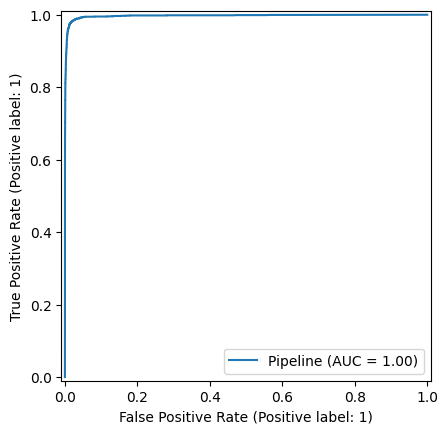

In [ ]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test);

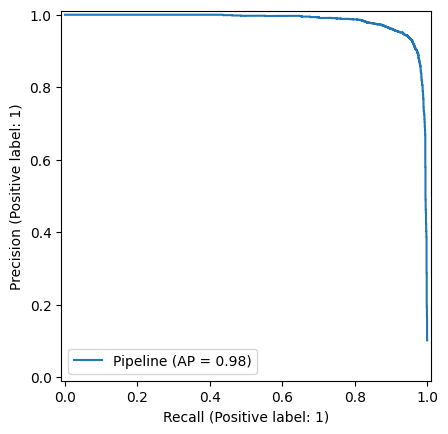

In [ ]:
PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test);

## Выводы

- была натренирована модель, предсказывающая токсичность комментариев
    - выбрана наиболее оптимальная модель - **LogisticRegression**, показавшая наилучшие результаты:
        - качество предсказания На тестовой выборке: f1 = 0.94
        - это удовлетворяет заданный критерий качества: f1 >= 0.75